# Multimodal RAG - Upsert & Query on Qdrant

2 collections: `fixed_size`, `semantic`

- Text chunks -> `bkai-foundation-models/vietnamese-bi-encoder` (768d, `text_vector`)
- Image chunks -> `sentence-transformers/clip-ViT-B-32` (512d, `image_vector`) - supports Vietnamese
- Image chunks -> `models/clip-vit-b32-finetuned-final-final/best` (512d, `image_vector_finetuned`)

## Text Upsert

In [24]:
# ── 2. Imports & Config ─────────────────────────────────────────────────────
import csv
import hashlib
import math
import re
from pathlib import Path

from qdrant_client import QdrantClient
from qdrant_client.models import (
    VectorParams,
    SparseVector,
    SparseVectorParams,
    Modifier,
    Distance,
    PointStruct,
    NamedVector,
)
from tqdm.auto import tqdm
import pandas as pd
import sentence_transformers

import torch
import numpy as np
from PIL import Image
from sentence_transformers import SentenceTransformer

# ── Config ──────────────────────────────────────────────────────────────────
QDRANT_URL  = "http://localhost:6333"
RECREATE_COLLECTIONS = True
COLLECTIONS = {
    "fixed_size": "fixed_size",
    "semantic":   "semantic",
}
V2_COLLECTIONS = {
    "fixed_size": "v2_fixed_size_hybrid",
    "semantic":   "v2_semantic_hybrid",
}
CHUNK_CSV = {
    "fixed_size": "../chunking_scripts/chunks_fixed_size.csv",
    "semantic":   "../chunking_scripts/chunks_semantic.csv",
}

# Embedding models
BKVEC_MODEL   = "bkai-foundation-models/vietnamese-bi-encoder"   # text -> 768d
IMG_MODEL      = "sentence-transformers/clip-ViT-B-32"  # image -> 512d
IMG_MODEL_FINETUNED = "../models/clip-vit-b32-finetuned-final-final/best"  # image -> 512d
V2_MODEL       = "jinaai/jina-clip-v2"  # text/image -> shared dense vector
TEXT_VEC_DIM  = 768
IMG_VEC_DIM   = 512
V2_VEC_DIM    = 512
SHARED_VECTOR = "dense"
SPARSE_VECTOR = "sparse"
TOKEN_RE = re.compile(r"\w+", re.UNICODE)

def sparse_vector(text):
    counts = {}
    for token in TOKEN_RE.findall(str(text or "").lower()):
        digest = hashlib.blake2b(token.encode("utf-8"), digest_size=8).digest()
        idx = int.from_bytes(digest, "big") % 2_147_483_647
        counts[idx] = counts.get(idx, 0) + 1

    indices = sorted(counts)
    values = [1.0 + math.log(counts[idx]) for idx in indices]
    norm = math.sqrt(sum(v * v for v in values)) or 1.0
    return SparseVector(indices=indices, values=[v / norm for v in values])



In [25]:
# ── 3. Connect to Qdrant ────────────────────────────────────────────────────
client = QdrantClient(url=QDRANT_URL)
info = client.info()
print(f"Qdrant {info.version} | collections: {[c.name for c in client.get_collections().collections]}")

Qdrant 1.18.0 | collections: ['fixed_size', 'semantic', 'v1_fixed_size', 'v1_semantic']


In [3]:
# ── 4. Create collections ───────────────────────────────────────────────────
for name, coll in COLLECTIONS.items():
    if client.collection_exists(coll):
        if RECREATE_COLLECTIONS:
            client.delete_collection(coll)
            print(f"[DELETED] '{coll}'")
        else:
            print(f"[SKIP] '{coll}' already exists")
            continue
    client.create_collection(
        collection_name=coll,
        vectors_config={
            "text_vector":  VectorParams(size=TEXT_VEC_DIM, distance=Distance.COSINE),  # 768d bkai
            "image_vector": VectorParams(size=IMG_VEC_DIM,  distance=Distance.COSINE),  # 512d CLIP
            "image_vector_finetuned": VectorParams(size=IMG_VEC_DIM, distance=Distance.COSINE),  # 512d fine-tuned CLIP
        },
        sparse_vectors_config={
            SPARSE_VECTOR: SparseVectorParams(modifier=Modifier.IDF),
        },
    )
    print(f"[CREATED] '{coll}' - text_vector({TEXT_VEC_DIM}d) + image_vector({IMG_VEC_DIM}d) + image_vector_finetuned({IMG_VEC_DIM}d) + {SPARSE_VECTOR}")
print("\nDone.")

[CREATED] 'fixed_size' - text_vector(768d) + image_vector(512d) + image_vector_finetuned(512d) + sparse
[CREATED] 'semantic' - text_vector(768d) + image_vector(512d) + image_vector_finetuned(512d) + sparse

Done.


In [4]:
import pandas as pd

chunks_by_coll = {}
for strat, csv_path in CHUNK_CSV.items():
    # Đọc toàn bộ CSV vào DataFrame
    df = pd.read_csv(csv_path, encoding="utf-8-sig")
    
    # Lọc data cực nhanh bằng vectorization của Pandas
    # Sau đó chuyển ngược về dạng list of dicts (.to_dict('records')) 
    # để tương thích với hàm upsert() của bạn
    texts = df[df["modality"] == "text"].to_dict('records')
    # imgs  = df[df["modality"] == "image"].to_dict('records')
    
    chunks_by_coll[strat] = {"text": texts}
    print(f"{COLLECTIONS[strat]}: {len(texts)} text")

fixed_size: 26054 text
semantic: 12858 text


In [26]:
# Xác định thiết bị (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Batch sizes
TEXT_BATCH = 16   # bkai: 768d
IMG_BATCH  = 8    # CLIP ViT-B/32: 512d

# =====================================================================
# 1. BKAi (Text -> 768d)
# =====================================================================
print("Loading bkai...")
bkai_model = SentenceTransformer(BKVEC_MODEL, device=device)

def embed_text_bkai(texts: list[str]) -> list[list[float]]:
    if not texts:
        return []
        
    embeddings = bkai_model.encode(
        texts,
        batch_size=TEXT_BATCH,
        normalize_embeddings=True, # Tự động làm L2-normalization
        convert_to_numpy=True,
        show_progress_bar=False
    )
    return embeddings.tolist()



Device: cuda
Loading bkai...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [6]:
# ── 7. Upsert (embed first, then batch-upload) ──────────────────────────────
import uuid


BATCH = 256

def _build_payload(row):
    return {
        "chunk_id":     row["chunk_id"],
        "modality":     row["modality"],
        "row_id":       int(row["row_id"]),
        "chunk_index":  int(row["chunk_index"]),
        "text":         row["text"],
        "image_path":   row["image_path"],
        "text_chunk_id": row.get("text_chunk_id", ""),
        "source":       row["source"],
        "url":          row["url"],
        "title":        row["title"],
        "author":       row["author"],
        "date":         row["date"],
        "corpus_id":    int(row["corpus_id"]),
    }

def upsert(strategy: str):
    coll = COLLECTIONS[strategy]
    rows = chunks_by_coll[strategy]

    # --- text chunks (bkai → 768d) -----------------------------------------
    text_rows = rows["text"]
    if text_rows:
        print(f"[{coll}] Embedding {len(text_rows)} text chunks with bkai...")
        text_embs = embed_text_bkai([r["text"] for r in text_rows])

        text_points = [
            PointStruct(
                id=str(uuid.uuid5(uuid.NAMESPACE_DNS, f"{r['row_id']}_{r['chunk_index']}")),
                vector={
                    "text_vector": emb,
                    SPARSE_VECTOR: sparse_vector(r["text"]),
                },
                payload=_build_payload(r),
            )
            for r, emb in zip(text_rows, text_embs)
        ]
        print(f"[{coll}] Upserting {len(text_points)} text points...")
        # for i in range(0, len(text_points), BATCH):
        #     client.upsert(collection_name=coll, points=text_points[i:i+BATCH])
        client.upload_points(collection_name=coll, points=text_points, batch_size=BATCH)
        print(f"[{coll}] Text upsert done.")

for strat in COLLECTIONS:
    upsert(strat)
print("\nAll text collections upserted.")


[fixed_size] Embedding 26054 text chunks with bkai...
[fixed_size] Upserting 26054 text points...
[fixed_size] Text upsert done.
[semantic] Embedding 12858 text chunks with bkai...
[semantic] Upserting 12858 text points...
[semantic] Text upsert done.

All text collections upserted.


## Image Upsert

In [8]:
corpus = pd.read_csv("../FinalDataset/final_corpus.csv", encoding="utf-8-sig")

In [9]:
# 2. Viết hàm tách chuỗi media thành list các đường dẫn
def split_media(media_str):
    if pd.isna(media_str):
        return []
    return {p.strip() for p in str(media_str).split(' | ') if p.strip()}

# Tạo cột mới 'image_path' chứa list các đường dẫn
corpus['image_path'] = corpus['media'].apply(split_media)

# 3. Explode DataFrame
# Bước này sẽ bung list trong 'image_path' thành nhiều dòng
# Các dòng không có ảnh (NaN) sẽ bị loại bỏ
df_exploded = corpus.explode('image_path').dropna(subset=['image_path'])

print(f"Tổng số ảnh trích xuất được (bao gồm có thể trùng lặp/lỗi): {len(df_exploded)}")

# 4. Lấy danh sách các đường dẫn UNIQUE để kiểm tra (tiết kiệm thời gian check I/O)
unique_paths = df_exploded['image_path'].unique()

Tổng số ảnh trích xuất được (bao gồm có thể trùng lặp/lỗi): 9085


In [10]:
from concurrent.futures import ThreadPoolExecutor
import os

def is_valid_image(path):
    path = os.path.join("./FinalDataset", path)
    if not (os.path.exists(path) and os.path.isfile(path)):
        return False
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img = img.convert("RGB")
            return img.width > 1 and img.height > 1
    except Exception:
        return False

# 5. Chạy kiểm tra song song
print(f"Đang kiểm tra {len(unique_paths)} đường dẫn duy nhất...")
with ThreadPoolExecutor(max_workers=10) as executor:
    results = list(executor.map(is_valid_image, unique_paths))

# Tạo một tập hợp (set) chứa các đường dẫn HỢP LỆ để tra cứu siêu tốc
valid_paths_set = set([path for path, is_valid in zip(unique_paths, results) if is_valid])

# 6. Lọc lại DataFrame, chỉ giữ những dòng có image_path nằm trong danh sách hợp lệ
df_valid = df_exploded[df_exploded['image_path'].isin(valid_paths_set)].copy()

print(f"Số lượng payload hợp lệ có thể tạo: {len(df_valid)}")


Đang kiểm tra 8880 đường dẫn duy nhất...
Số lượng payload hợp lệ có thể tạo: 0


In [27]:
# =====================================================================
# 2. CLIP-ViT (Image -> 512d)
# =====================================================================
print("Loading CLIP-ViT models...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_model = SentenceTransformer(IMG_MODEL, device=device)
img_model_finetuned = SentenceTransformer(IMG_MODEL_FINETUNED, device=device)
dimension = img_model.get_sentence_embedding_dimension()
dimension_finetuned = img_model_finetuned.get_sentence_embedding_dimension()
print(f"Original CLIP embedding dimension: {dimension}")
print(f"Fine-tuned CLIP embedding dimension: {dimension_finetuned}")
if dimension != IMG_VEC_DIM:
    raise ValueError(f"Expected original CLIP dimension {IMG_VEC_DIM}, got {dimension}")
if dimension_finetuned != IMG_VEC_DIM:
    raise ValueError(f"Expected fine-tuned CLIP dimension {IMG_VEC_DIM}, got {dimension_finetuned}")



def load_valid_image(path):
    """Load a valid RGB image and skip corrupt or 1x1 placeholder files."""
    path = os.path.join("./FinalDataset", path)
    if not (os.path.exists(path) and os.path.isfile(path)):
        return None
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img = img.convert("RGB").copy()
        if img.width <= 1 or img.height <= 1:
            return None
        return img
    except Exception:
        return None

def embed_image_clip_with_model(image_paths: list[str], model: SentenceTransformer, output_dim: int) -> list[list[float]]:
    """Embed image hiện đại: Xử lý an toàn các file hỏng để không làm lệch index khi zip() upsert."""
    if not image_paths:
        return []
    
    # print(image_paths)
    # return []
    # Khởi tạo trước một ma trận toàn số 0.
    # Nếu ảnh hỏng, nó sẽ giữ nguyên vector [0, 0, ..., 0]
    final_embs = np.zeros((len(image_paths), output_dim), dtype=np.float32)
    
    valid_images = []
    valid_indices = []
    
    # Chỉ load những ảnh hợp lệ và lưu lại vị trí (index) gốc của nó
    for idx, path in enumerate(image_paths):
        img = load_valid_image(path)
        if img is not None:
            valid_images.append(img)
            valid_indices.append(idx)
        else:
            print(f"[WARN] Invalid image skipped: {path}")
            
    # Tiến hành embed toàn bộ ảnh hợp lệ một lần
    if valid_images:
        valid_embs = model.encode(
            valid_images,
            batch_size=8,
            normalize_embeddings=True, # Tự động làm L2-normalization
            convert_to_numpy=True,
            show_progress_bar=False
        )
        
        # Lắp ráp các vector hợp lệ về đúng vị trí index gốc của chúng
        for i, original_idx in enumerate(valid_indices):
            final_embs[original_idx] = valid_embs[i]
            
    return final_embs.tolist()

def embed_image_clip(image_paths: list[str]) -> list[list[float]]:
    return embed_image_clip_with_model(image_paths, img_model, dimension)

def embed_image_clip_finetuned(image_paths: list[str]) -> list[list[float]]:
    return embed_image_clip_with_model(image_paths, img_model_finetuned, dimension_finetuned)

def embed_text_clip(query: str) -> list[float]:
    return img_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )[0].tolist()

def embed_text_clip_finetuned(query: str) -> list[float]:
    return img_model_finetuned.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )[0].tolist()


Loading CLIP-ViT models...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Original CLIP embedding dimension: 512
Fine-tuned CLIP embedding dimension: 512


C:\Users\Admin\AppData\Local\Temp\ipykernel_16920\1228638586.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension = img_model.get_sentence_embedding_dimension()
C:\Users\Admin\AppData\Local\Temp\ipykernel_16920\1228638586.py:10: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  dimension_finetuned = img_model_finetuned.get_sentence_embedding_dimension()


In [ ]:
 # --- image chunks (CLIP-ViT -> 512d) -------------------------------------
# img_rows = rows["image"]
# if not img_rows:
#     print(f"[{coll}] No image chunks. Skipping.")
#     return
from ast import MatchValue
import gc
import uuid
import math

from qdrant_client.grpc import FieldCondition
from qdrant_client.models import Filter


def _build_payload_image(row):
    return {
        "modality":     "image",
        "corpus_id":       int(row["id"]),
        "image_path":   row["image_path"],
        "source":       row["source"],
        "url":          row["url"],
        "title":        row["title"],
        "author":       row["author"],
        "date":         row["date"],
    }

def upsert_images(collection: str, df_valid: pd.DataFrame, batch_size: int = 128):
    total_images = len(df_valid)
    num_batches = math.ceil(total_images / batch_size)
    
    print(f"[{collection}] Bắt đầu xử lý {total_images} ảnh, chia thành {num_batches} batches (kích thước {batch_size})...")
    
    # Bọc vòng lặp bằng tqdm
    for i in tqdm(range(num_batches), desc=f"[{collection}] Upserting", unit="batch"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, total_images)
        
        # 1. Cắt lấy 1 batch
        df_batch = df_valid.iloc[start_idx:end_idx]
        
        # 2. Embed
        try:
            image_paths = df_batch["image_path"].tolist()
            batch_embs = embed_image_clip(image_paths)
            batch_embs_finetuned = embed_image_clip_finetuned(image_paths)
        except Exception as e:
            # Dùng tqdm.write thay vì print để không làm trôi/vỡ thanh tiến trình
            tqdm.write(f"\n[{collection}] Lỗi khi embed batch {i+1}: {e}")
            continue
            
        assert len(batch_embs) == len(df_batch), f"Lệch số lượng vector gốc ở batch {i+1}!"
        assert len(batch_embs_finetuned) == len(df_batch), f"Lệch số lượng vector fine-tuned ở batch {i+1}!"

        # 3. Build PointStruct
        batch_points = [
            PointStruct(
                id=str(uuid.uuid5(uuid.NAMESPACE_DNS, f"{r['id']}_{r['image_path']}")),
                vector={
                    "image_vector": emb,
                    "image_vector_finetuned": emb_finetuned,
                },
                payload=_build_payload_image(r),
            )
            for r, emb, emb_finetuned in zip(df_batch.to_dict(orient="records"), batch_embs, batch_embs_finetuned)
        ]
        
        # 4. Upload
        client.upload_points(collection_name=collection, points=batch_points)
        
        # 5. Dọn dẹp RAM
        del df_batch, image_paths, batch_embs, batch_embs_finetuned, batch_points
        gc.collect()

    print(f"[{collection}] Hoàn tất Image upsert.")
    
    
from qdrant_client import models


for strat in COLLECTIONS:
    coll = COLLECTIONS[strat]
    client.delete(
        collection_name=coll,
        points_selector=Filter(
            must=[
                models.FieldCondition(
                    key="modality",
                    match=models.MatchValue(value="image"),
                ),
            ]
        )
    )
    print(f"[{coll}] Đã xóa tất cả điểm có modality='image'. Bắt đầu upsert lại...")
    print(f"\n{'='*50}")
    upsert_images(coll, df_valid, batch_size=512)

## Testing

In [29]:
# ── 9. Collection stats ─────────────────────────────────────────────────────
for name, coll in COLLECTIONS.items():
    info = client.get_collection(coll)
    print(f"{coll}: {info.points_count} points  |  indexed on text_vector + image_vector + image_vector_finetuned + sparse")


fixed_size: 35087 points  |  indexed on text_vector + image_vector + image_vector_finetuned + sparse
semantic: 21891 points  |  indexed on text_vector + image_vector + image_vector_finetuned + sparse


Query: thủ tướng
Collection: semantic



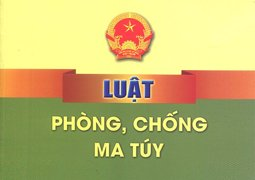
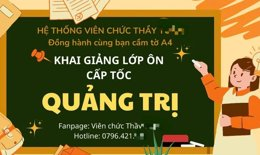
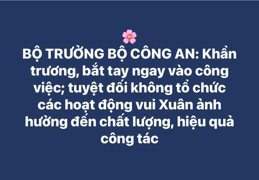
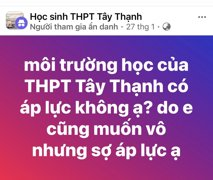
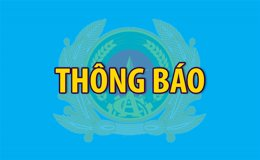
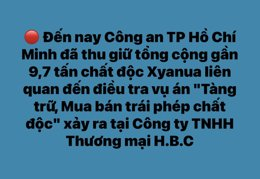
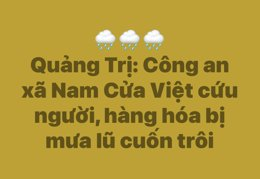
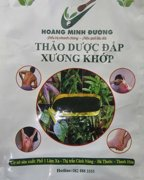


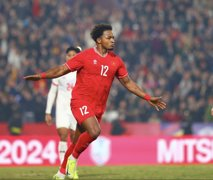
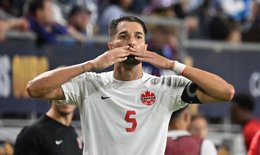
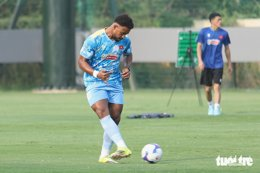
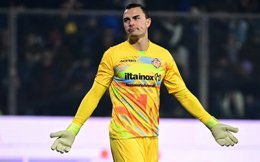
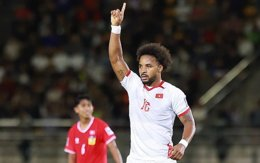
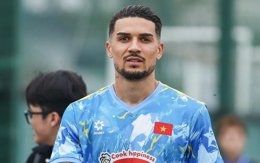
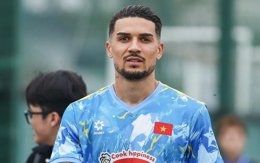
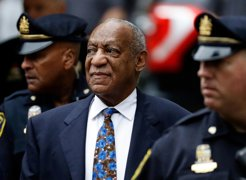

In [35]:
# ── 10. Cross-modal testing: text query -> image results ────────────────────
import base64
import html
import io
from IPython.display import HTML, display

IMAGE_ROOT = Path("../FinalDataset")

def search_images_by_text(query: str, collection: str, vector_name: str, query_vector: list[float], top_k: int = 8):
    """Search only image points with a CLIP text embedding against an image vector field."""
    results = client.query_points(
        collection_name=collection,
        query=query_vector,
        using=vector_name,
        query_filter=models.Filter(
            must=[
                models.FieldCondition(
                    key="modality",
                    match=models.MatchValue(value="image"),
                )
            ]
        ),
        limit=top_k,
        with_payload=True,
        with_vectors=False,
    )
    return results.points

def _resolve_image_path(image_path: str) -> Path:
    path = Path(str(image_path))
    if path.exists():
        return path
    return IMAGE_ROOT / path

def _image_data_uri(image_path: str, max_size: tuple[int, int] = (260, 180)) -> str | None:
    path = _resolve_image_path(image_path)
    if not path.exists():
        return None
    try:
        with Image.open(path) as img:
            img = img.convert("RGB")
            img.thumbnail(max_size)
            buffer = io.BytesIO()
            img.save(buffer, format="JPEG", quality=85)
        return "data:image/jpeg;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")
    except Exception:
        return None

def display_image_results(title: str, points):
    cards = []
    for rank, point in enumerate(points, start=1):
        payload = point.payload or {}
        image_path = payload.get("image_path", "")
        data_uri = _image_data_uri(image_path)
        img_html = (
            f'<img src="{data_uri}" style="width:100%;height:150px;object-fit:contain;background:#f6f6f6;border:1px solid #ddd;" />'
            if data_uri
            else '<div style="height:150px;display:flex;align-items:center;justify-content:center;background:#f6f6f6;border:1px solid #ddd;color:#777;">missing image</div>'
        )
        cards.append(f"""
        <div style="border:1px solid #ddd;border-radius:6px;padding:8px;min-width:220px;max-width:260px;">
          {img_html}
          <div style="font:13px/1.4 sans-serif;margin-top:6px;">
            <b>#{rank}</b> score={point.score:.4f}<br>
            <span>{html.escape(str(payload.get('title', ''))[:90])}</span><br>
            <code style="font-size:11px;white-space:normal;word-break:break-word;">{html.escape(str(image_path))}</code>
          </div>
        </div>
        """)
    display(HTML(f"""
    <h3 style="font-family:sans-serif;margin:14px 0 8px;">{html.escape(title)}</h3>
    <div style="display:flex;gap:10px;flex-wrap:wrap;align-items:flex-start;">{''.join(cards)}</div>
    """))

def compare_text_to_image_search(query: str, collection: str = COLLECTIONS["semantic"], top_k: int = 8):
    original_results = search_images_by_text(
        query=query,
        collection=collection,
        vector_name="image_vector",
        query_vector=embed_text_clip(query),
        top_k=top_k,
    )
    finetuned_results = search_images_by_text(
        query=query,
        collection=collection,
        vector_name="image_vector_finetuned",
        query_vector=embed_text_clip_finetuned(query),
        top_k=top_k,
    )
    print(f"Query: {query}")
    print(f"Collection: {collection}")
    display_image_results("Original CLIP: text -> image_vector", original_results)
    display_image_results("Fine-tuned CLIP: text -> image_vector_finetuned", finetuned_results)
    return {"original": original_results, "finetuned": finetuned_results}

# Change this query to evaluate recall manually.
TEST_QUERY = "thủ tướng"
comparison_results = compare_text_to_image_search(TEST_QUERY, collection=COLLECTIONS["semantic"], top_k=8)